In [180]:
%pip install xgboost
%pip install catboost
%pip install scikeras
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 7.3/351.2 MB 43.7 MB/s eta 0:00:08
   - -------------------------------------- 16.8/351.2 MB 45.7 MB/s eta 0:00:08
   -- ------------------------------------- 24.9/351.2 MB 43.8 MB/s eta 0:00:08
   ---- ----------------------------------- 36.2/351.2 MB 45.9 MB/s eta 0:00:07
   ----- ---------------------------------- 46.7/351.2 MB 47.0 MB/s eta 0:00:07
   ------ --------------------------------- 57.1/351.2 MB 48.0 MB/s eta 0:00:07
   ------- -------------------------------- 68.7/351.2 MB 49.3 MB/s eta 0:00:06
   --------- ------------------------------ 80.5/351.2 MB 50.4 MB/s eta 0:00:06
   ---------- -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [96]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import ConfusionMatrixDisplay

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import joblib
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier

import warnings

from itertools import combinations

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import precision_recall_curve


import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
import networkx as nx

from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from sklearn.metrics import f1_score

In [5]:
dir = os.getcwd()
print(dir)

C:\Users\grego\OneDrive\Documents\Projects\App_PredictFlakingType


In [72]:
df = pd.read_csv(dir+"/Quartz energetics_flakes.csv")
df = df[df['Completeness'] == 'Complete']

target = 'Flaking condition'

df['Elong'] = df['TechLength']/df['MaxTechWidth']
df['PlatElong'] = df['PlatformThickness']/df['PlatformWidth']

cols_drop = ['DateOfDataEntry', 'CoreNumber', 'NumberPlatformScars', 'ToolNumber', 'QuartzGrainSize', 'QuartzGrain',
             'QuartzPlane', 'LithicArtifactClass', 'Completeness', 'Notes', 'Photograph',
             'ReboundForce', 'DiagnosticImpactFractures', 'DorsalPrep',
             
             'MaxLength', 'MaxWidth', 'MidThickness', 'MaxTechWidth', 'TechLength',
             'PlatformWidth', 'PlatformThickness'
            ]

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

df[target] = df[target].map({'Bipolar': 0, 'Freehand': 1})

In [75]:
df.shape

(284, 29)

# Examine variable collinearity

In [76]:
numeric_df = df.drop([target], axis = 1).select_dtypes(include=['float64', 'int64'])

# Drop rows with NaN or infinite values
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF for numeric columns only
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print(vif_data)
vif_num = vif_data['feature'].tolist()

             feature       VIF
0    DorsalScarCount  3.795357
1       MaxThickness  9.874994
2  ExteriorPlatAngle  4.744778
3               Mass  3.638311
4          Curvature  1.245949
5              Elong  3.934718
6          PlatElong  4.829559


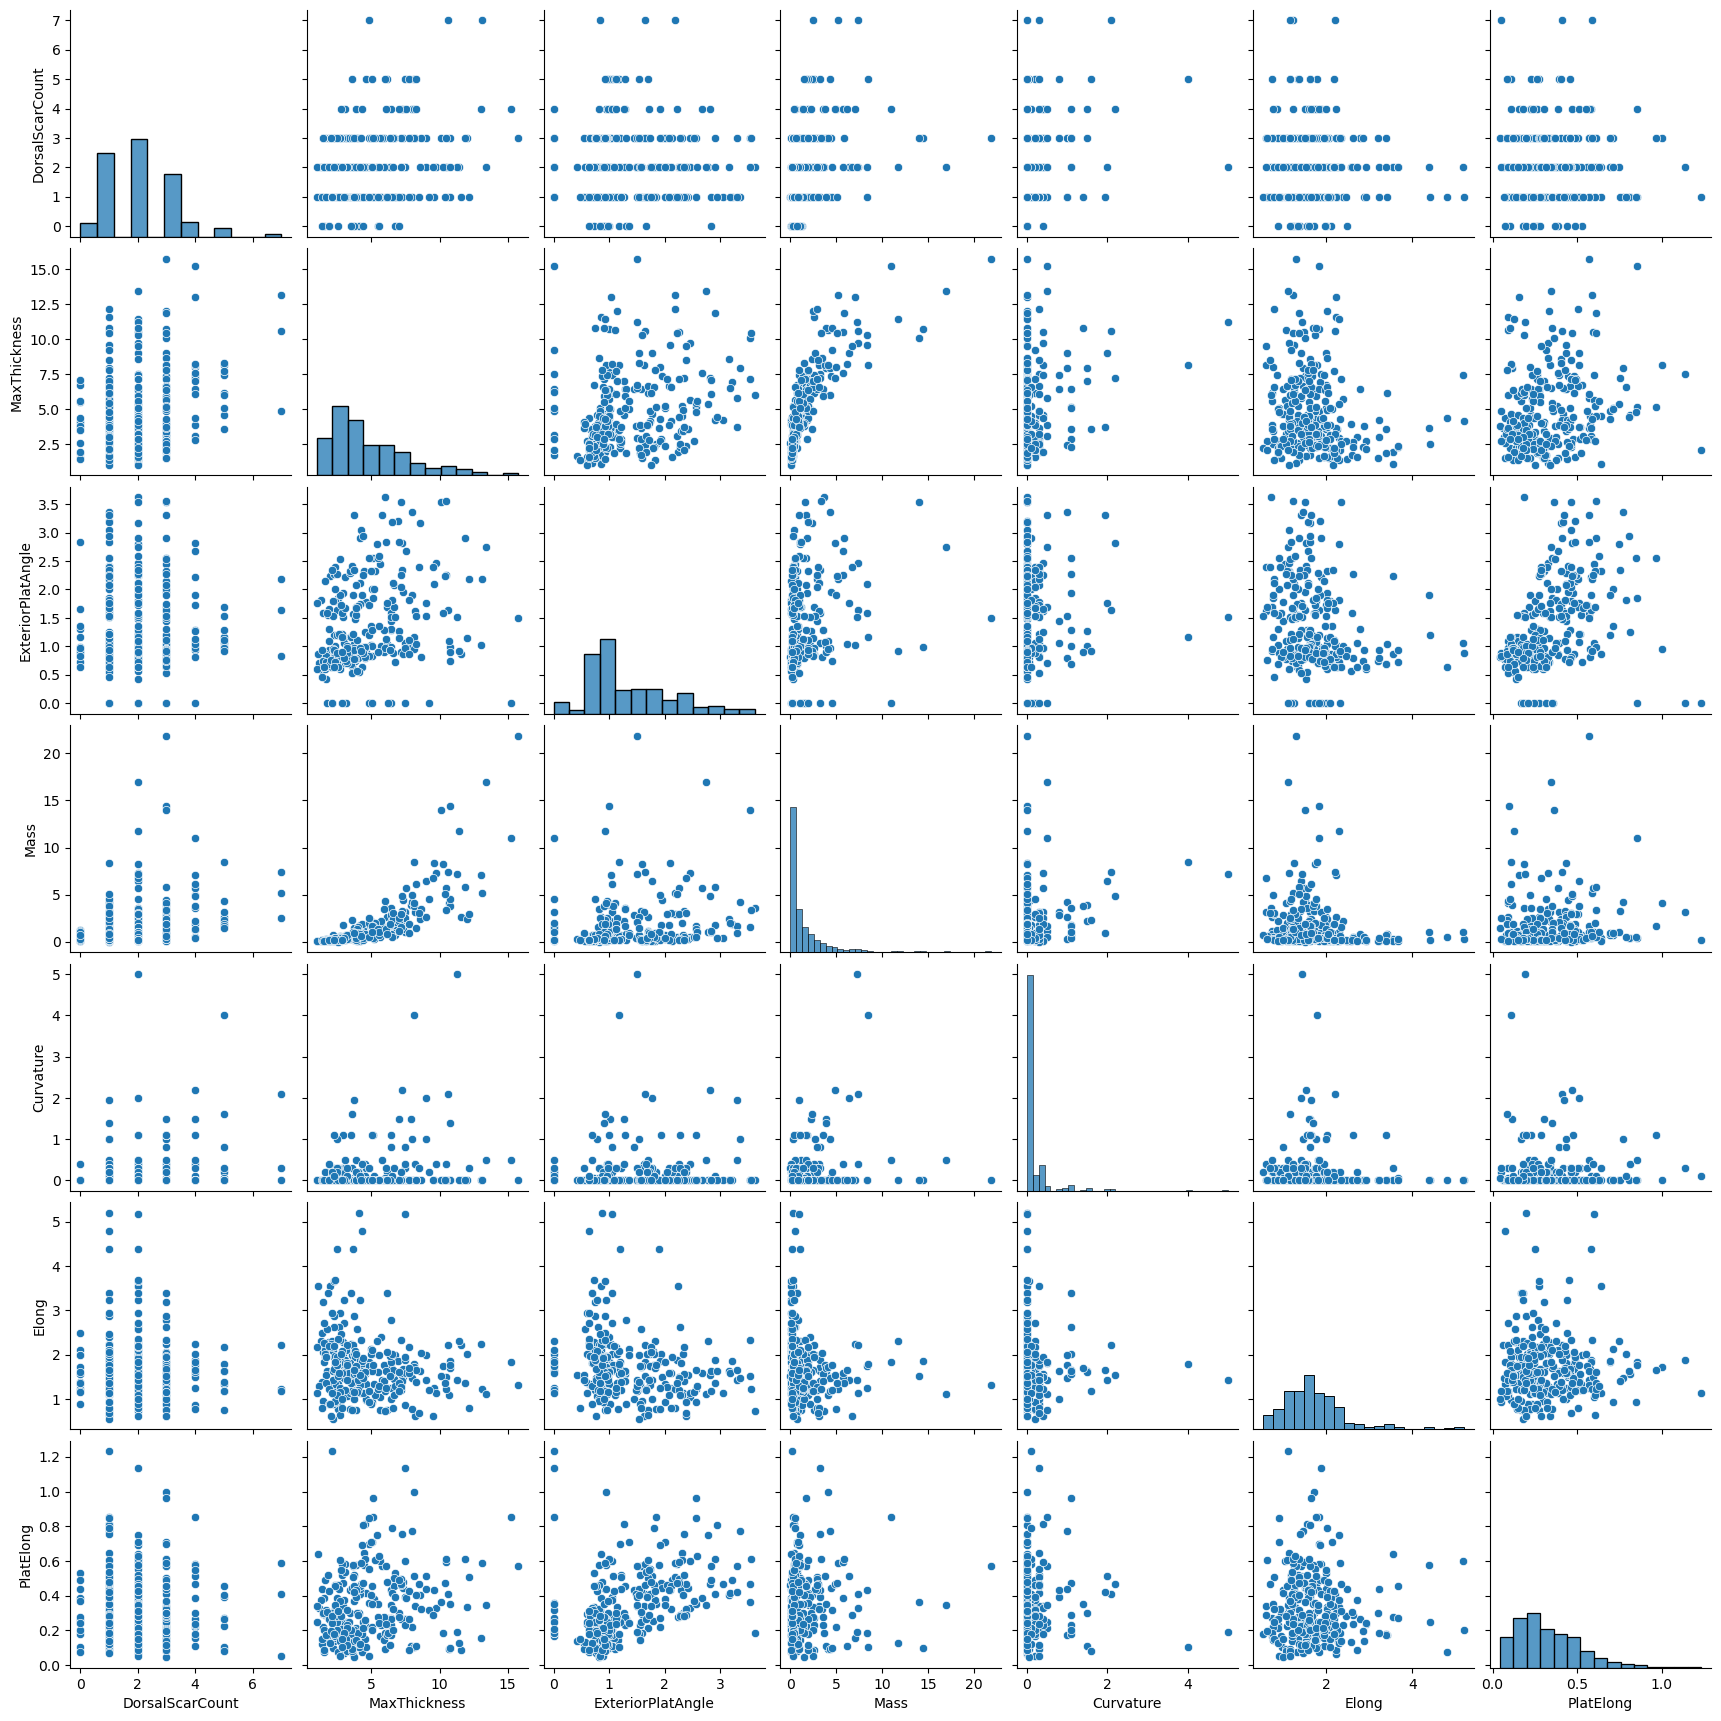

In [9]:
sns.pairplot(numeric_df)
plt.show()

In [77]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_cat = df[cat_cols]
target_df = df[target]
#df_cat.drop(['Flaking condition'], axis = 1, inplace = True)
cat_cols = df_cat.select_dtypes(include=['object', 'category']).columns
p_values = pd.DataFrame(index=cat_cols, columns=cat_cols)

# Drop rows with NaN or infinite values
df_cat = df_cat.replace([np.inf, -np.inf], np.nan).dropna()

In [78]:
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

def cramers_v_matrix(df):
    cols = df.columns
    matrix = pd.DataFrame(np.zeros((len(cols), len(cols))),
                          columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(i, len(cols)):
            v = cramers_v(df[cols[i]], df[cols[j]])
            matrix.iloc[i, j] = v
            matrix.iloc[j, i] = v

    return matrix

# run
v_matrix = cramers_v_matrix(df_cat)
#print(v_matrix)

C:\Users\grego\AppData\Local\Temp\ipykernel_5824\1074193394.py:7: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\grego\AppData\Local\Temp\ipykernel_5824\1074193394.py:7: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\grego\AppData\Local\Temp\ipykernel_5824\1074193394.py:7: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\grego\AppData\Local\Temp\ipykernel_5824\1074193394.py:7: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\grego\AppData\Local\Temp\ipykernel_5824\1074193394.py:7: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\grego\AppData\Local\Temp\ipykernel_5824\1074193394.py:7: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\g

In [79]:
threshold = 0.8
high_assoc = v_matrix > threshold
G = nx.Graph()

for col in v_matrix.columns:
    G.add_node(col)

for i in range(len(v_matrix.columns)):
    for j in range(i+1, len(v_matrix.columns)):
        if v_matrix.iloc[i, j] > threshold:
            G.add_edge(v_matrix.columns[i], v_matrix.columns[j])

clusters = list(nx.connected_components(G))
print(clusters)

[{'EvidenceBipolarPercussion'}, {'TechnicalCategory'}, {'FlakeProfile'}, {'CortexArea'}, {'PlatformCortex'}, {'CortexLocation'}, {'DorsalDirection'}, {'ArisOrientation'}, {'CrossSectionType'}, {'ProfileTwisted?'}, {'FlakeTermination'}, {'PlatformPrep'}, {'PlatAbrasion'}, {'FractureInitiationPoint'}, {'PlatformDelineation'}, {'FissuringOnPlatform'}, {'MarksVentralSurface'}, {'Lipping'}, {'PlatformMorphology'}, {'EdgeDamage'}, {'EPACaliper'}]


In [80]:
def pick_best_feature(cluster, target, df):
    
    best_feature = None
    best_score = -1
    
    for col in cluster:
        contingency = pd.crosstab(df[col], df[target])
        chi2, _, _, _ = chi2_contingency(contingency)
        
        if chi2 > best_score:
            best_score = chi2
            best_feature = col
            
    return best_feature

selected_features = []

for cluster in clusters:
    if len(cluster) == 1:
        selected_features.append(list(cluster)[0])
    else:
        best = pick_best_feature(cluster, 'Flaking condition', df_cat)
        selected_features.append(best)

print(selected_features)

['EvidenceBipolarPercussion', 'TechnicalCategory', 'FlakeProfile', 'CortexArea', 'PlatformCortex', 'CortexLocation', 'DorsalDirection', 'ArisOrientation', 'CrossSectionType', 'ProfileTwisted?', 'FlakeTermination', 'PlatformPrep', 'PlatAbrasion', 'FractureInitiationPoint', 'PlatformDelineation', 'FissuringOnPlatform', 'MarksVentralSurface', 'Lipping', 'PlatformMorphology', 'EdgeDamage', 'EPACaliper']


In [81]:
df = df[selected_features+vif_num+[target]]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
np.isinf(df.select_dtypes(include=['number'])).any()

DorsalScarCount      False
MaxThickness         False
ExteriorPlatAngle    False
Mass                 False
Curvature            False
Elong                False
PlatElong            False
Flaking condition    False
dtype: bool

# Develop and Evaluate Models

In [82]:
df.head()

,EvidenceBipolarPercussion,TechnicalCategory,FlakeProfile,CortexArea,PlatformCortex,CortexLocation,DorsalDirection,ArisOrientation,CrossSectionType,ProfileTwisted?,...,EdgeDamage,EPACaliper,DorsalScarCount,MaxThickness,ExteriorPlatAngle,Mass,Curvature,Elong,PlatElong,Flaking condition
0,No,A3,Parallel,91-99%,YesComplete,WholeDorsal,Bidirectional,Indeterminate,Other,No,...,No,Small,2,2.89,1.94,1.78,1.1,2.020125,0.472693,1
1,No,B7,Converging,11-40%,YesComplete,Distal,Unidirectional,Parallel,Trapezoidal,Yes,...,No,Small,3,7.35,1.96,4.45,0.0,1.503034,0.446125,1
2,No,B1,Ovoid,0%,No,NaN,Unidirectional,Indeterminate,Domed,No,...,No,Small,5,6.15,1.70,2.60,0.2,0.749218,0.272727,1
4,No,B4,Expanding,11-40%,YesComplete,Distal,Subradial,Convergent,Triangular,No,...,No,Small,2,9.04,1.77,6.43,2.0,1.426168,0.512739,1
7,Yes,A3,Parallel,91-99%,YesComplete,WholeDorsal,NaN,NaN,NaN,Yes,...,No,Small,1,9.60,2.10,8.32,0.0,1.255301,0.432343,0


In [83]:
models = {
    'model': [LogisticRegression(), RandomForestClassifier(), XGBClassifier(eval_metric='logloss')],
    'param_grid': [
        {
        'model__C': [0.01, 0.1, 1, 10, 100], 
        'model__penalty': ['l1', 'l2', 'none'],      
        'model__solver': ['liblinear']        
    },
        {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 7, 10]
                   },
        {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 6, 9],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample': [0.8, 1.0]
        }
                  ]
}

In [97]:
def run_model(data, features, target, model, params):
    X = data[features]
    #if str(type(model)) == "<class 'xgboost.sklearn.XGBClassifier'>":
        #y = data[target].map({"Freehand": 1, "Bipolar": 0})
    #else:
    y = data[target]
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

    numeric_features = X_train.select_dtypes(include='number').columns.tolist()
    categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

    num_pipeline = Pipeline([
        ("imputer", IterativeImputer()),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipeline, numeric_features),
        ("cat", cat_pipeline, categorical_features)
    ])

    pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
    ])

    param_grid = params

    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # Proportion Correct
    accuracy = accuracy_score(y_test, y_pred)
    # Type I Error Rate (False Positive Rate)
    type_i_error = fp / (fp + tn)
    # Type II Error Rate (False Negative Rate)
    type_ii_error = fn / (fn + tp)

    f1 = f1_score(y_test, y_pred)
    

    return {'accuracy': accuracy,
            'type I error': type_i_error,
            'type II error': type_ii_error,
            'best parameters': grid.best_params_,
            'best_model':grid.best_estimator_,
            'model': model,
            'f1': f1}

## All featur combos

In [147]:
final_keys = "set_"
final_count = 1

features = [c for c in df.columns if c != target]
best_of_the_best = {}

keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model']
best_model = {key: [] for key in keys} 

for r in range(1, len(features) + 1):
    for combo in combinations(features, r):
        for model in range(3):
            feat = df[list(combo)]
            targ = df[target]




            with warnings.catch_warnings():
                warnings.simplefilter('ignore')

                model_test = run_model(
                        data = df,
                        features = feat.columns,
                        target = target,
                        model = models['model'][model],
                        params = models['param_grid'][model]
                                      )
                best_model['accuracy'].append(model_test['accuracy'])
                best_model['model'].append(model_test['model'])
                best_model['best_model'].append(model_test['best_model'])

        if len(best_model['accuracy']) > 0:

            max_accuracy = max(best_model['accuracy'])
            max_index = best_model['accuracy'].index(max_accuracy)
            best_model_instance = {'model': best_model['model'][max_index],
                                   'accuracy': best_model['accuracy'][max_index],
                                   'features': feat.columns.tolist(),
                                   'best_estimator': best_model['best_model'][max_index]
                                  }
            #print(f"Maximum accuracy: {max_accuracy}")
        else:
            print("The accuracy list is empty")
            best_model_instance = {'model': [],
                                    'accuracy': [],
                                    'features': []}

        best_of_the_best[final_keys+str(final_count)] = best_model_instance
        final_count = final_count + 1
        best_model = {key: [] for key in keys}



#joblib.dump(best_of_the_best, "model_registry.pkl")


KeyboardInterrupt



## Select feature combos

In [98]:
input_feats = df.drop([target], axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num]
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])

In [101]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "all_feature_model.pkl")

['all_feature_model.pkl']

In [102]:
input_feats = ['FlakeTermination', 'PlatformPrep', 'PlatAbrasion',
              'Lipping', 'MaxThickness', 'Mass', 'Elong', 'PlatElong']

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num]
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])

In [104]:
best_model['f1']

[0.6842105263157895, 0.6857142857142857, 0.5882352941176471]

In [105]:
best_of_the_best = best_model['best_model'][1]
joblib.dump(best_of_the_best, "sbf_model.pkl")

['sbf_model.pkl']

## Keras model

In [112]:
def build_model(input_dim=input_dim):
    
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

X = df[['FlakeTermination', 'PlatformPrep', 'PlatAbrasion',
    'Lipping', 'MaxThickness', 'Mass', 'Elong', 'PlatElong']]
y = df[target]
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7770)


numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
input_dim = X_train_transformed.shape[1]  # Get the actual number of features after transformation
print(f"Input dimension: {input_dim}")


param_grid = {
    "nn__epochs": [30, 50],
    "nn__batch_size": [16, 32]
}

clf = KerasClassifier(
    model=build_model,
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

pipeline = Pipeline([
    ("nn", clf)
])
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_transformed, y_train)

Input dimension: 19


ValueError: 
All the 20 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\grego\anaconda3\Lib\site-packages\scikeras\wrappers.

In [113]:
X_test_transformed = preprocessor.transform(X_test)
y_pred = grid.best_estimator_.predict(X_test_transformed)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(accuracy)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [114]:
y_probs = grid.best_estimator_.predict(X_test_transformed)

fpr, tpr, thresholds = roc_curve(y_true_enc, y_probs)

roc_auc = auc(fpr, tpr)
f1 = f1_score(y_test, y_probs)
print(f1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Freehand', 'Bipolar'])
disp.plot()
plt.show()

plt.figure()
plt.plot(fpr, tpr, label=f'Keras Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [66]:
y_true_enc
y_probs

array([0.54764223, 0.6185492 , 0.6616789 , 0.89786863, 0.91586083,
       0.52573633, 0.87841046, 0.75255287, 0.88112825, 0.6878952 ,
       0.91524476, 0.75454   , 0.6530341 , 0.8655474 , 0.2675622 ,
       0.5392045 , 0.5126474 , 0.7886492 , 0.8086427 , 0.45474315,
       0.462376  , 0.39055735, 0.4988395 , 0.86033094, 0.86010504,
       0.87459373, 0.81502557, 0.48456424, 0.768572  , 0.79059196,
       0.84288776, 0.49659604, 0.52760834, 0.9490752 , 0.65076244,
       0.5527265 , 0.9382651 , 0.8082488 , 0.7075797 , 0.7788792 ,
       0.813169  , 0.48520505, 0.5214889 , 0.95422   , 0.9254968 ,
       0.1308142 , 0.89999145, 0.7135724 , 0.8894962 , 0.35422707,
       0.4788475 , 0.85943156, 0.72615314, 0.867671  , 0.53193337,
       0.48157763, 0.6023897 ], dtype=float32)

In [239]:
df = pd.read_csv(dir+"/Quartz energetics_flakes.csv")

df = df[df['Completeness'] == 'Complete']

cols_drop = ['DateOfDataEntry', 'CoreNumber', 'ToolNumber', 'QuartzGrainSize', 'QuartzGrain',
             'QuartzPlane', 'LithicArtifactClass', 'Completeness', 'Notes', 'Photograph']

            'NumberPlatformScars', 'CortexLocation', 'ReboundForce', 'DorsalPrep',
            'FissuringOnPlatform', 'MarksVentralSurface', 'DiagnosticImpactFractures',
            'EvidenceBipolarPercussion','MaxWidth', 'MidThickness', 'PlatformPrep', 'PlatAbrasion',
            'EdgeDamage', 'EPACaliper', 'MaxLength',
            # Test dropping
            'TechnicalCategory', 'FlakeProfile', 'CortexArea', 'FractureInitiationPoint','FractureInitiationPoint','PlatformCortex',
            
            #Test 2
            'DorsalScarCount', 'DorsalDirection', 'ArisOrientation', 'CrossSectionType', 'ProfileTwisted?',
            
            # Test 3
            'Curvature','ExteriorPlatAngle','PlatformMorphology', 'PlatformDelineation']

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

Best Params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


C:\Users\grego\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit

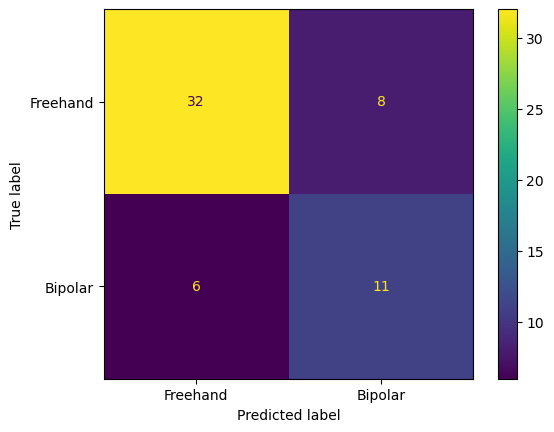

                            Coefficient
FlakeTermination_Overshoot     2.300841
PlatformThickness              2.164713
FlakeTermination_Feather       1.563662
MaxTechWidth                   0.909830
FlakeTermination_Axial         0.821243
PlatformWidth                  0.075679
Accuracy: 0.75
Type I Error Rate: 0.20
Type II Error Rate: 0.35


['flaking_pipeline.pkl']

In [257]:
X = df.drop(['Flaking condition'], axis = 1)
y = df['Flaking condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])

# Corrected parameter grid with proper prefixes
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100], 
    'model__penalty': ['l1', 'l2', 'none'],      
    'model__solver': ['liblinear']        
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Fixed variable name from grid_search to grid
print(f"Best Params: {grid.best_params_}")

# Fixed variable name from grid_search to grid
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Freehand', 'Bipolar'])
disp.plot()
plt.show()

preprocessor = best_model.named_steps['preprocess']
model = best_model.named_steps['model']  # Access the model step

# Get feature names after one-hot encoding
feature_names = []
if numeric_features:
    feature_names.extend(numeric_features)
if categorical_features:
    # Get the one-hot encoded feature names
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = ohe.get_feature_names_out(categorical_features)
    feature_names.extend(cat_features)

# Create DataFrame with coefficients
coef_df = pd.DataFrame(
    model.coef_[0],  # Access coef_ from the model, not the pipeline
    index=feature_names,
    columns=['Coefficient']
).sort_values(by='Coefficient', ascending=False)

print(coef_df[coef_df['Coefficient'] > 0])

# Extract counts from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(f"Accuracy: {accuracy:.2f}")
print(f"Type I Error Rate: {type_i_error:.2f}")
print(f"Type II Error Rate: {type_ii_error:.2f}")

In [222]:
df.drop(['Flaking condition'], axis = 1).to_csv('Test.csv', index = False)

# Random Forest Classifier

Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


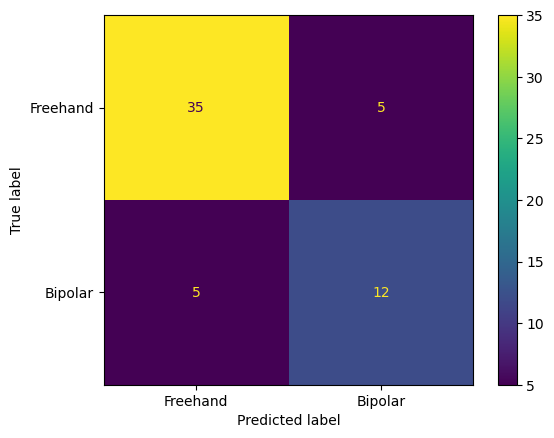

In [258]:
X = df.drop(['Flaking condition'], axis = 1)
y = df['Flaking condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

# Corrected parameter grid with proper prefixes
param_grid = {
    'model__n_estimators': [100, 150, 200],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 7, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Fixed variable name from grid_search to grid
print(f"Best Params: {grid.best_params_}")

# Fixed variable name from grid_search to grid
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Freehand', 'Bipolar'])
disp.plot()
plt.show()

preprocessor = best_model.named_steps['preprocess']
model = best_model.named_steps['model']  # Access the model step

# Extract counts from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(f"Accuracy: {accuracy:.2f}")
print(f"Type I Error Rate: {type_i_error:.2f}")
print(f"Type II Error Rate: {type_ii_error:.2f}")

## XGBoost

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 1.0}


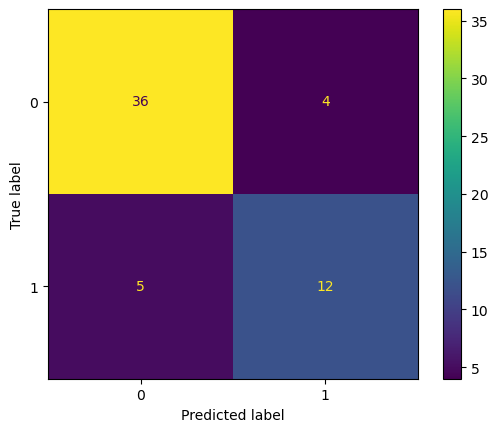

Accuracy: 0.84
Type I Error Rate: 0.10
Type II Error Rate: 0.29


['flaking_pipeline.pkl']

In [278]:
X = df.drop(['Flaking condition'], axis = 1)
y_encoded = df["Flaking condition"].map({"Freehand": 1, "Bipolar": 0})

#label_encoder = LabelEncoder()

#y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=777)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(eval_metric='logloss'))
])

# Corrected parameter grid with proper prefixes
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0]
}


grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Fixed variable name from grid_search to grid
print(f"Best Params: {grid.best_params_}")

# Fixed variable name from grid_search to grid
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Extract counts from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(f"Accuracy: {accuracy:.2f}")
print(f"Type I Error Rate: {type_i_error:.2f}")
print(f"Type II Error Rate: {type_ii_error:.2f}")

joblib.dump(grid.best_estimator_, "flaking_pipeline.pkl")

## CatBoost

In [290]:
from platform import python_version
print(python_version())

3.13.9
